In [5]:
#Izhikevich Model 
#v is membrane potential variable
#u is recovery  variable
#Hopf bifurcation

import numpy as np
import matplotlib.pyplot as plt

def ODE(a,b,c,d,I,u,v,T):
    vaxis = []
    uaxis = []
    spike_times = []
    dt = 0.05
    n_steps = int(T / dt)
    for i in range(n_steps):
        vaxis.append(v)
        uaxis.append(u)
        dv = 0.04*v**2 + 5*v + 140 - u + I
        du = a * (b*v - u)
        v = v + dv * dt
        u = u + du * dt 
        if v >= 30: 
            v = c
            u = u + d
            spike_times.append((i + 1) * dt)
    return uaxis, vaxis, spike_times

I_values= np.linspace(3.5,4.1, 61)
for I in I_values:
    _, _, spike_times = ODE(0.02, 0.2, -65, 8, I, -13, -65, 3000)

    count = 0
    for t in spike_times:
        if t >= 2000:
            count  = count + 1
    if 3.75 < I < 3.90:
        print(I, count)


3.76 0
3.7699999999999996 0
3.78 5
3.79 6
3.8 5
3.8099999999999996 6
3.82 6
3.8299999999999996 6
3.84 6
3.8499999999999996 6
3.86 6
3.8699999999999997 6
3.88 7
3.8899999999999997 7


In [6]:
I_values= np.linspace(3.5,4.1, 61)
for I in I_values:
    _, _, spike_times = ODE(0.02, 0.2, -65, 8, I, -12.47, -62.34, 3000)

    count = 0
    for t in spike_times:
        if t >= 2000:
            count  = count + 1
    if 3.75 < I < 3.90:
        print(I, count)


3.76 0
3.7699999999999996 0
3.78 0
3.79 0
3.8 5
3.8099999999999996 5
3.82 6
3.8299999999999996 6
3.84 7
3.8499999999999996 6
3.86 6
3.8699999999999997 6
3.88 7
3.8899999999999997 7


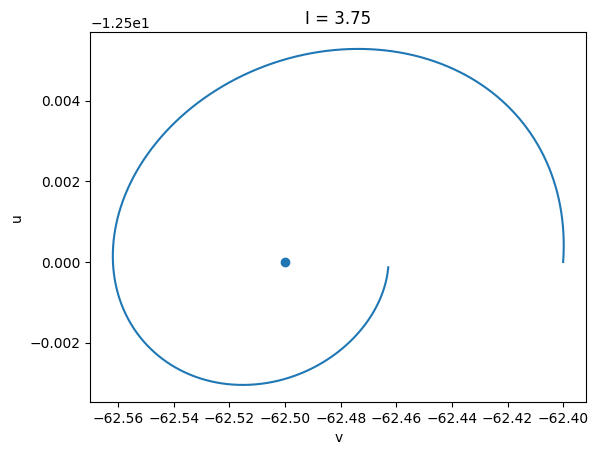

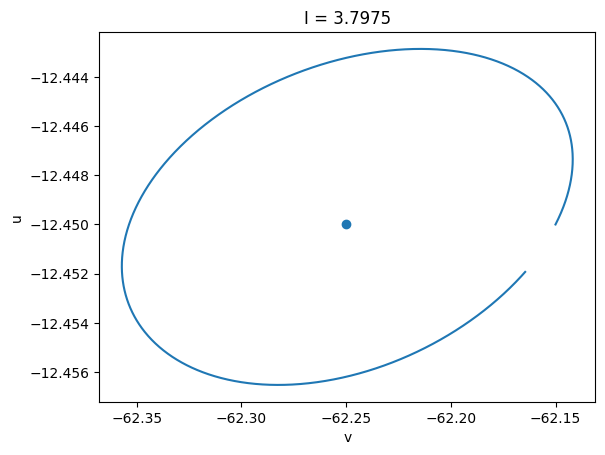

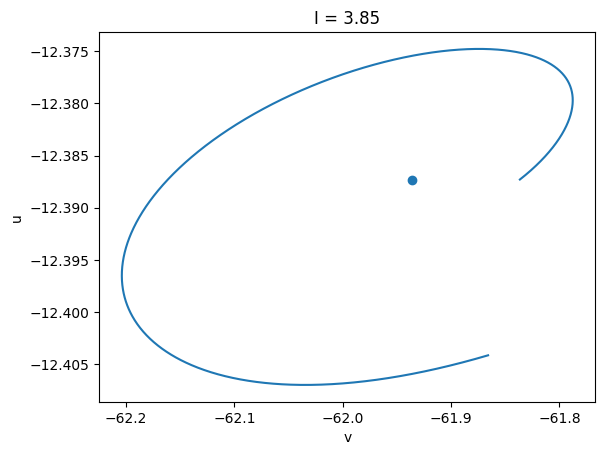

In [13]:
#To remind us of Hop bifurcation. It occurs, when Jacobi eigenvalues are two complex conjugate roots, and they erach to the imaginary axis. So, we just need to set the trace(Jacobi) = 0, and then solving that and evaluating det(Jacobi) at that point we got sth around \pm 0.06i. (All reason for this was ofcourse the characteristic of Jacobi J^2 - trace(J) J + det(J)I = 0), and setting trace(J) = 0, we will have the roots to meet each other on the imaginary axis, and Hopf bifurcation will happen. 
I_values = [3.75, 3.7975, 3.85]
for I in I_values: 
    #Here ew first calculate the equilibrium for each I value. If you llok at the ODE for different values of I first we need to set v\dot = 0, and hence we solve the quadratic, and for the second one u_eq = 0.2 v_eq. Then we will evalute the solution of ODE around the equilibrium and we expect to see linear contraction/expansion to vanish for I = 3.7975 Hopf bifurcation occurs. 
    v_eq = (-4.8 - np.sqrt(0.64 - 0.16*I)) / 0.08
    u_eq = 0.2*v_eq
    #perturb the equilibrium points a bit, so we won't get exact 0. 
    v0 = v_eq + 0.1
    u0 = u_eq
    uaxis, vaxis, _ = ODE(0.02, 0.2, -65, 8, I, u0, v0, 100)
    plt.figure()
    plt.plot(vaxis,uaxis)
    plt.scatter(v_eq, u_eq)
    plt.title(f"I = {I}")
    plt.xlabel("v")
    plt.ylabel("u")
    plt.show()

